In [1]:
# Basic Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Audio Processing Libraries
import librosa
import librosa.display

# Deep Learning Libraries (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LSTM, Bidirectional, SimpleRNN
from tensorflow.keras.layers import TimeDistributed, BatchNormalization, Activation, Reshape, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
# Sklearn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Misc
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
import os
import random

# Set seed for reproducibility
random.seed(42)

# Dataset root path
dataset_path = '/kaggle/input/the-fake-or-real-dataset/'

# Function to split files into train/val/test
def split_files(files, train_ratio=0.7, val_ratio=0.2):
    random.shuffle(files)
    total = len(files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)
    
    train_files = files[:train_count]
    val_files = files[train_count:train_count + val_count]
    test_files = files[train_count + val_count:]
    
    return train_files, val_files, test_files
    
# Process each subfolder (like "for-2sec", "for-norm", etc.)
for subfolder in sorted(os.listdir(dataset_path)):
    subfolder_path = os.path.join(dataset_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue  # Skip files, only process folders

    # Collect all files (including nested files if present)
    all_files = []
    for root, _, files in os.walk(subfolder_path):
        for file in files:
            file_path = os.path.join(root, file)
            all_files.append(file_path)

    # Split files into train/val/test
    train_files, val_files, test_files = split_files(all_files)

    # Format folder name for display
    folder_display_name = subfolder.replace('-', ' ')

    # Print progress exactly like your example
    print(f"\n📂 Loading Data for: {subfolder}/{folder_display_name}")
    print(f"✅ training set - {len(train_files)} samples")
    print(f"✅ validation set - {len(val_files)} samples")
    print(f"✅ testing set - {len(test_files)} samples")

# Final confirmation
print("\n✅ Data Loading Completed!")


📂 Loading Data for: for-2sec/for 2sec
✅ training set - 12509 samples
✅ validation set - 3574 samples
✅ testing set - 1787 samples

📂 Loading Data for: for-norm/for norm
✅ training set - 48510 samples
✅ validation set - 13860 samples
✅ testing set - 6930 samples

📂 Loading Data for: for-original/for original
✅ training set - 48521 samples
✅ validation set - 13863 samples
✅ testing set - 6932 samples

📂 Loading Data for: for-rerec/for rerec
✅ training set - 9287 samples
✅ validation set - 2653 samples
✅ testing set - 1328 samples

✅ Data Loading Completed!


In [2]:
import os
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm

# Paths
INPUT_DIR = "/kaggle/input/the-fake-or-real-dataset"
OUTPUT_DIR = "/kaggle/working/cleaned_audio"

# Parameters
TARGET_SAMPLE_RATE = 16000
TARGET_DURATION = 3.0  # 3 seconds
N_MFCC = 13  # Standard number of MFCC coefficients
N_MELS = 64  # Good balance for deep learning
HOP_LENGTH = 512
WIN_LENGTH = 1024

# Create output directory if not exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get total files count (for progress tracking)
def count_files():
    count = 0
    for _, _, files in os.walk(INPUT_DIR):
        count += len(files)
    return count

# Preprocess audio and extract features
def process_and_extract_features(file_path, base_save_path):
    try:
        # Load audio
        audio, sr = librosa.load(file_path, sr=TARGET_SAMPLE_RATE, mono=True)

        # Trim/pad to exactly 3 seconds
        target_length = int(TARGET_DURATION * TARGET_SAMPLE_RATE)
        if len(audio) > target_length:
            audio = audio[:target_length]
        elif len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))

        # Normalize
        audio = librosa.util.normalize(audio)

        # Extract Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Extract MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)

        # Save both features
        np.save(f"{base_save_path}_mel.npy", mel_spec_db)
        np.save(f"{base_save_path}_mfcc.npy", mfcc)

        return True
        
    except Exception as e:
        print(f"\n❌ Skipped {file_path}: {e}")
        return False    

# Full cleaning & feature extraction pipeline
def clean_and_process_all():
    total_files = count_files()
    processed_files = 0

    file_list = []
    for root, _, files in os.walk(INPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            save_base = os.path.join(OUTPUT_DIR, os.path.relpath(root, INPUT_DIR), os.path.splitext(file)[0])
            os.makedirs(os.path.dirname(save_base), exist_ok=True)
            file_list.append((file_path, save_base))

    for i, (file_path, save_base) in enumerate(file_list):
        if process_and_extract_features(file_path, save_base):
            processed_files += 1

        # Show progress
        progress = (i + 1) / total_files * 100
        print(f"\r🚀 Processing: {progress:.2f}% completed ({processed_files}/{total_files} files processed)", end='', flush=True)

    print("\n✅ All files processed and features saved!")
    print(f"📂 Files saved in: {OUTPUT_DIR}")

# Run the process
clean_and_process_all()


🚀 Processing: 41.24% completed (69999/169754 files processed)
❌ Skipped /kaggle/input/the-fake-or-real-dataset/for-original/for-original/validation/fake/file31606.mp3: 
🚀 Processing: 43.77% completed (74296/169754 files processed)
❌ Skipped /kaggle/input/the-fake-or-real-dataset/for-original/for-original/validation/fake/file16165.mp3: 
🚀 Processing: 47.26% completed (80218/169754 files processed)
❌ Skipped /kaggle/input/the-fake-or-real-dataset/for-original/for-original/training/fake/file17407.mp3: 
🚀 Processing: 47.43% completed (80504/169754 files processed)
❌ Skipped /kaggle/input/the-fake-or-real-dataset/for-original/for-original/training/fake/file19851.mp3: 
🚀 Processing: 48.60% completed (82493/169754 files processed)
❌ Skipped /kaggle/input/the-fake-or-real-dataset/for-original/for-original/training/fake/file5323.mp3: 
🚀 Processing: 49.16% completed (83441/169754 files processed)
❌ Skipped /kaggle/input/the-fake-or-real-dataset/for-original/for-original/training/fake/file31017.m

In [2]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Ensure GPU is being used
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/working/cleaned_audio/for-2sec/for-2seconds/'},
]

# ✅ Load dataset (Training, Validation, Testing)
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and preprocess data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for CNN input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# ✅ Define Advanced CNN Model
def create_cnn_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1), padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ✅ Create & Train Model
model = create_cnn_model()
history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/cnn_optimized.h5")
print("\n✅ Optimized Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.7482 - loss: 0.5120 - val_accuracy: 0.6585 - val_loss: 0.9445
Epoch 2/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8824 - loss: 0.2714 - val_accuracy: 0.8751 - val_loss: 0.2896
Epoch 3/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9245 - loss: 0.1849 - val_accuracy: 0.8280 - val_loss: 0.4754
Epoch 4/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9407 - loss: 0.1525 - val_accuracy: 0.8234 - val_loss: 0.5638
Epoch 5/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9553 - loss: 0.1155 - val_accuracy: 0.9611 - val_loss: 0.1193
Epoch 6/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9625 - loss: 0.1070 - val_accuracy: 0.9731 - val_loss: 0.0839
Epoch 7/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9640 - loss: 0.0966 - val_accuracy: 0.8754 - val_loss: 0.4151
Epoch 8/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.

In [3]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Ensure GPU is being used
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset paths
datasets = [
    {'name': 'for-norm', 'path': '/kaggle/working/cleaned_audio/for-norm/for-norm/'},
   
]

# ✅ Load dataset (Training, Validation, Testing)
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and preprocess data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for CNN input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# ✅ Define Advanced CNN Model
def create_cnn_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1), padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ✅ Create & Train Model
model = create_cnn_model()
history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/cnn_optimized.h5")
print("\n✅ Optimized Model Saved Successfully!")

Num GPUs Available: 2
Epoch 1/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.8852 - loss: 0.2853 - val_accuracy: 0.8960 - val_loss: 0.3017
Epoch 2/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9615 - loss: 0.1068 - val_accuracy: 0.9747 - val_loss: 0.0744
Epoch 3/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9752 - loss: 0.0725 - val_accuracy: 0.9555 - val_loss: 0.1299
Epoch 4/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9815 - loss: 0.0541 - val_accuracy: 0.9469 - val_loss: 0.1775
Epoch 5/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9843 - loss: 0.0450 - val_accuracy: 0.9809 - val_loss: 0.0583
Epoch 6/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9879 - loss: 0.0364 - val_accuracy: 0.8473 - val_loss: 0.8306
Epoch 7/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9890 - loss: 0.0331 - val_accuracy: 0.9914 - val_loss: 0.0302
Epoch 8/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/ste

In [2]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Ensure GPU is being used
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset paths
datasets = [
    {'name': 'for-original', 'path': '/kaggle/working/cleaned_audio/for-original/for-original/'},
]

# ✅ Load dataset (Training, Validation, Testing)
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and preprocess data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for CNN input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# ✅ Define Advanced CNN Model
def create_cnn_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1), padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ✅ Create & Train Model
model = create_cnn_model()
history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/cnn_optimized.h5")
print("\n✅ Optimized Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - accuracy: 0.9090 - loss: 0.2264 - val_accuracy: 0.9254 - val_loss: 0.1863
Epoch 2/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9738 - loss: 0.0756 - val_accuracy: 0.8473 - val_loss: 0.4737
Epoch 3/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9823 - loss: 0.0511 - val_accuracy: 0.9849 - val_loss: 0.0466
Epoch 4/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9878 - loss: 0.0370 - val_accuracy: 0.9908 - val_loss: 0.0296
Epoch 5/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9900 - loss: 0.0294 - val_accuracy: 0.9513 - val_loss: 0.1685
Epoch 6/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9923 - loss: 0.0245 - val_accuracy: 0.9824 - val_loss: 0.0499
Epoch 7/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - accuracy: 0.9936 - loss: 0.0183 - val_accuracy: 0.9552 - val_loss: 0.1766
Epoch 8/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/ste

In [3]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Ensure GPU is being used
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset paths
datasets = [

    {'name': 'for-rerec', 'path': '/kaggle/working/cleaned_audio/for-rerec/for-rerecorded/'}
]

# ✅ Load dataset (Training, Validation, Testing)
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and preprocess data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for CNN input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# ✅ Define Advanced CNN Model
def create_cnn_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1), padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ✅ Create & Train Model
model = create_cnn_model()
history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/cnn_optimized.h5")
print("\n✅ Optimized Model Saved Successfully!")

Num GPUs Available: 2
Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.6568 - loss: 0.6362 - val_accuracy: 0.5579 - val_loss: 1.5598
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8056 - loss: 0.4215 - val_accuracy: 0.6199 - val_loss: 1.7663
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8453 - loss: 0.3471 - val_accuracy: 0.6266 - val_loss: 1.6947
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8660 - loss: 0.3035 - val_accuracy: 0.7478 - val_loss: 0.8350
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8800 - loss: 0.2770 - val_accuracy: 0.7344 - val_loss: 0.9771
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8995 - loss: 0.2397 - val_accuracy: 0.8422 - val_loss: 0.4769
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9065 - loss: 0.2185 - val_accuracy: 0.7112 - val_loss: 1.0443
Epoch 8/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9220 - 

In [29]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Enable Mixed Precision for Faster Training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ✅ Check GPU Availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset Paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/working/cleaned_audio/for-2sec/for-2seconds/'}
]

# ✅ Load Dataset
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and Preprocess Data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for RNN Input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Convert to tf.data for Efficient Loading
def create_tf_dataset(X, Y, batch_size=64):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(X_train, Y_train_cat)
val_dataset = create_tf_dataset(X_val, Y_val_cat)
test_dataset = create_tf_dataset(X_test, Y_test_cat)

# ✅ Define Advanced RNN Model (LSTM + GRU)
def create_rnn_model():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(GRU(256, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(512, return_sequences=False, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=True)
    return model

# ✅ Create & Train Model
model = create_rnn_model()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/rnn_optimized.h5")
print("\n✅ Optimized RNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5871 - loss: 0.9430 - val_accuracy: 0.6723 - val_loss: 0.5609
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6755 - loss: 0.6936 - val_accuracy: 0.7438 - val_loss: 0.4927
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7363 - loss: 0.5794 - val_accuracy: 0.8209 - val_loss: 0.3884
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7516 - loss: 0.5258 - val_accuracy: 0.8284 - val_loss: 0.3669
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7775 - loss: 0.4718 - val_accuracy: 0.8309 - val_loss: 0.3667
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8060 - loss: 0.4348 - val_accuracy: 0.8549 - val_loss: 0.3296
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8105 - loss: 0.4090 - val_accuracy: 0.8535 - val_loss: 0.3209
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8286 - 

In [30]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Enable Mixed Precision for Faster Training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ✅ Check GPU Availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset Paths
datasets = [
    {'name': 'for-norm', 'path': '/kaggle/working/cleaned_audio/for-norm/for-norm/'}
]

# ✅ Load Dataset
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and Preprocess Data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for RNN Input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Convert to tf.data for Efficient Loading
def create_tf_dataset(X, Y, batch_size=64):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(X_train, Y_train_cat)
val_dataset = create_tf_dataset(X_val, Y_val_cat)
test_dataset = create_tf_dataset(X_test, Y_test_cat)

# ✅ Define Advanced RNN Model (LSTM + GRU)
def create_rnn_model():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(GRU(256, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(512, return_sequences=False, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=True)
    return model

# ✅ Create & Train Model
model = create_rnn_model()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/rnn_optimized.h5")
print("\n✅ Optimized RNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.7498 - loss: 0.6556 - val_accuracy: 0.8427 - val_loss: 0.3702
Epoch 2/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.8159 - loss: 0.4469 - val_accuracy: 0.8560 - val_loss: 0.3432
Epoch 3/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.8375 - loss: 0.3894 - val_accuracy: 0.8642 - val_loss: 0.3260
Epoch 4/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.8514 - loss: 0.3574 - val_accuracy: 0.8687 - val_loss: 0.3287
Epoch 5/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.8621 - loss: 0.3317 - val_accuracy: 0.8812 - val_loss: 0.2953
Epoch 6/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.8700 - loss: 0.3112 - val_accuracy: 0.8850 - val_loss: 0.2805
Epoch 7/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.8800 - loss: 0.2917 - val_accuracy: 0.8969 - val_loss: 0.2528
Epoch 8/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.

In [32]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Enable Mixed Precision for Faster Training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ✅ Check GPU Availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset Paths
datasets = [
  {'name': 'for-original', 'path': '/kaggle/working/cleaned_audio/for-original/for-original/'}
]

# ✅ Load Dataset
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and Preprocess Data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for RNN Input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Convert to tf.data for Efficient Loading
def create_tf_dataset(X, Y, batch_size=64):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(X_train, Y_train_cat)
val_dataset = create_tf_dataset(X_val, Y_val_cat)
test_dataset = create_tf_dataset(X_test, Y_test_cat)

# ✅ Define Advanced RNN Model (LSTM + GRU)
def create_rnn_model():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(GRU(256, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(512, return_sequences=False, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=True)
    return model

# ✅ Create & Train Model
model = create_rnn_model()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/rnn_optimized.h5")
print("\n✅ Optimized RNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.8107 - loss: 0.5108 - val_accuracy: 0.9171 - val_loss: 0.2068
Epoch 2/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.8959 - loss: 0.2567 - val_accuracy: 0.9301 - val_loss: 0.1776
Epoch 3/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9176 - loss: 0.2028 - val_accuracy: 0.9427 - val_loss: 0.1392
Epoch 4/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9305 - loss: 0.1690 - val_accuracy: 0.9544 - val_loss: 0.1154
Epoch 5/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9455 - loss: 0.1409 - val_accuracy: 0.9614 - val_loss: 0.1033
Epoch 6/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9521 - loss: 0.1249 - val_accuracy: 0.9683 - val_loss: 0.0866
Epoch 7/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9621 - loss: 0.1006 - val_accuracy: 0.9743 - val_loss: 0.0725
Epoch 8/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.

In [33]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

# ✅ Enable Mixed Precision for Faster Training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ✅ Check GPU Availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ✅ Dataset Paths
datasets = [
{'name': 'for-rerec', 'path': '/kaggle/working/cleaned_audio/for-rerec/for-rerecorded/'}
]

# ✅ Load Dataset
def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}  # Label mapping

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):  # Using Mel Spectrograms
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

# ✅ Load and Preprocess Data
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

# Reshape for RNN Input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

# Convert labels to categorical
Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

# ✅ Convert to tf.data for Efficient Loading
def create_tf_dataset(X, Y, batch_size=64):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.shuffle(buffer_size=len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(X_train, Y_train_cat)
val_dataset = create_tf_dataset(X_val, Y_val_cat)
test_dataset = create_tf_dataset(X_test, Y_test_cat)

# ✅ Define Advanced RNN Model (LSTM + GRU)
def create_rnn_model():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(GRU(256, return_sequences=True, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(512, return_sequences=False, activation='tanh', recurrent_activation='sigmoid')),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=True)
    return model

# ✅ Create & Train Model
model = create_rnn_model()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30, verbose=1
)

# ✅ Predictions
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

# ✅ Compute Evaluation Metrics
accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:,1])
logloss = log_loss(Y_true_classes, Y_pred)
val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc  # Approximate EER calculation

# ✅ Display Metrics in Table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})
print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

# ✅ Save Model
model.save("/kaggle/working/rnn_optimized.h5")
print("\n✅ Optimized RNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.5562 - loss: 1.0751 - val_accuracy: 0.5793 - val_loss: 0.6593
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6055 - loss: 0.8854 - val_accuracy: 0.6716 - val_loss: 0.6099
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6413 - loss: 0.7950 - val_accuracy: 0.6943 - val_loss: 0.6064
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6611 - loss: 0.7483 - val_accuracy: 0.7072 - val_loss: 0.5728
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6828 - loss: 0.6907 - val_accuracy: 0.6952 - val_loss: 0.5969
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6803 - loss: 0.6721 - val_accuracy: 0.7313 - val_loss: 0.5211
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6926 - loss: 0.6277 - val_accuracy: 0.7161 - val_loss: 0.5925
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7129 - 

In [27]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, LSTM, Bidirectional, TimeDistributed)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import librosa

# ✅ Fix Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-rerec/for-rerecorded/"
# ✅ Set Fixed Shape for Features (Resize to Ensure Uniformity)
FIXED_HEIGHT = 64   # Keep consistent height
FIXED_WIDTH = 94    # Keep consistent width

# ✅ Load Features & Labels with Automatic Resizing
def load_features_and_labels(dataset_path):
    features, labels = [], []
    
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")
                
                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)
                    # ✅ Resize both features to the FIXED shape
                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    # Copy the actual data (avoiding shape mismatch)
                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))  # Folder name as label

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)  # Ensure labels are strings

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize (Avoid Divide by Zero)
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))
# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Define Model (CNN + LSTM for Best Accuracy)
model = keras.Sequential([
    Input(shape=(X.shape[1], X.shape[2], X.shape[3])),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    TimeDistributed(Flatten()),  # Fix shape issue before LSTM
    Bidirectional(LSTM(128, return_sequences=False)),  # LSTM for sequence learning

    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(len(label_encoder.classes_), activation='softmax')  # Final output layer
])

# ✅ Optimizer & Callbacks
optimizer = Adam(learning_rate=0.001)
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]
# ✅ Compile Model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audio_model_fixed.h5")
print("✅ Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Evaluation Metrics (Without AUC-ROC)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy  # Placeholder for EER

# ✅ Print Metrics
print("\n=== Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.7306 - loss: 0.5164 - val_accuracy: 0.4985 - val_loss: 0.7124 - learning_rate: 0.0010
Epoch 2/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8800 - loss: 0.2855 - val_accuracy: 0.8191 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 3/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9262 - loss: 0.1811 - val_accuracy: 0.5019 - val_loss: 3.7584 - learning_rate: 0.0010
Epoch 4/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9428 - loss: 0.1436 - val_accuracy: 0.9363 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 5/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9530 - loss: 0.1298 - val_accuracy: 0.7136 - val_loss: 1.1607 - learning_rate: 0.0010
Epoch 6/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9647 - loss: 0.0946 - val_accuracy: 0.9224 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 7/30
331/332 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9762 - loss: 0

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, LSTM, Bidirectional, TimeDistributed)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import librosa

# ✅ Fix Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-norm/for-norm/"
# ✅ Set Fixed Shape for Features (Resize to Ensure Uniformity)
FIXED_HEIGHT = 64   # Keep consistent height
FIXED_WIDTH = 94    # Keep consistent width

# ✅ Load Features & Labels with Automatic Resizing
def load_features_and_labels(dataset_path):
    features, labels = [], []
    
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")
                
                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)
                    # ✅ Resize both features to the FIXED shape
                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    # Copy the actual data (avoiding shape mismatch)
                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))  # Folder name as label

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)  # Ensure labels are strings

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize (Avoid Divide by Zero)
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))
# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Define Model (CNN + LSTM for Best Accuracy)
model = keras.Sequential([
    Input(shape=(X.shape[1], X.shape[2], X.shape[3])),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    TimeDistributed(Flatten()),  # Fix shape issue before LSTM
    Bidirectional(LSTM(128, return_sequences=False)),  # LSTM for sequence learning

    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(len(label_encoder.classes_), activation='softmax')  # Final output layer
])

# ✅ Optimizer & Callbacks
optimizer = Adam(learning_rate=0.001)
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]
# ✅ Compile Model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audio_model_fixed.h5")
print("✅ Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Evaluation Metrics (Without AUC-ROC)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy  # Placeholder for EER

# ✅ Print Metrics
print("\n=== Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")

Epoch 1/20
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.9293 - loss: 0.1769 - val_accuracy: 0.9153 - val_loss: 0.2373 - learning_rate: 0.0010
Epoch 2/20
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accuracy: 0.9902 - loss: 0.0278 - val_accuracy: 0.8390 - val_loss: 0.4578 - learning_rate: 0.0010
Epoch 3/20
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9934 - loss: 0.0193 - val_accuracy: 0.9190 - val_loss: 0.2401 - learning_rate: 0.0010
Epoch 4/20
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9958 - loss: 0.0116
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9958 - loss: 0.0116 - val_accuracy: 0.9154 - val_loss: 0.4080 - learning_rate: 0.0010
Epoch 5/20
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 0.9911 - val_loss: 0.0304 - learning_rate: 5.0000e-04
Epoch 6/20
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accu

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, LSTM, Bidirectional, TimeDistributed)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import librosa

# ✅ Fix Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-original/for-original/"
# ✅ Set Fixed Shape for Features (Resize to Ensure Uniformity)
FIXED_HEIGHT = 64   # Keep consistent height
FIXED_WIDTH = 94    # Keep consistent width

# ✅ Load Features & Labels with Automatic Resizing
def load_features_and_labels(dataset_path):
    features, labels = [], []
    
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")
                
                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)
                    # ✅ Resize both features to the FIXED shape
                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    # Copy the actual data (avoiding shape mismatch)
                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))  # Folder name as label

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)  # Ensure labels are strings

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize (Avoid Divide by Zero)
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))
# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Define Model (CNN + LSTM for Best Accuracy)
model = keras.Sequential([
    Input(shape=(X.shape[1], X.shape[2], X.shape[3])),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    TimeDistributed(Flatten()),  # Fix shape issue before LSTM
    Bidirectional(LSTM(128, return_sequences=False)),  # LSTM for sequence learning

    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(len(label_encoder.classes_), activation='softmax')  # Final output layer
])

# ✅ Optimizer & Callbacks
optimizer = Adam(learning_rate=0.001)
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]
# ✅ Compile Model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audio_model_fixed.h5")
print("✅ Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Evaluation Metrics (Without AUC-ROC)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy  # Placeholder for EER

# ✅ Print Metrics
print("\n=== Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.9592 - loss: 0.1039 - val_accuracy: 0.9966 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 2/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9953 - loss: 0.0149 - val_accuracy: 0.9757 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 3/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9964 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 4/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9970 - loss: 0.0094 - val_accuracy: 0.9986 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9986 - loss: 0.0049 - val_accuracy: 0.9991 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 6/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 0.9989 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 7/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accura

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, LSTM, Bidirectional, TimeDistributed)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import librosa

# ✅ Fix Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-2sec/for-2seconds/"
# ✅ Set Fixed Shape for Features (Resize to Ensure Uniformity)
FIXED_HEIGHT = 64   # Keep consistent height
FIXED_WIDTH = 94    # Keep consistent width

# ✅ Load Features & Labels with Automatic Resizing
def load_features_and_labels(dataset_path):
    features, labels = [], []
    
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")
                
                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)
                    # ✅ Resize both features to the FIXED shape
                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    # Copy the actual data (avoiding shape mismatch)
                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))  # Folder name as label

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)  # Ensure labels are strings

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize (Avoid Divide by Zero)
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))
# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Define Model (CNN + LSTM for Best Accuracy)
model = keras.Sequential([
    Input(shape=(X.shape[1], X.shape[2], X.shape[3])),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    TimeDistributed(Flatten()),  # Fix shape issue before LSTM
    Bidirectional(LSTM(128, return_sequences=False)),  # LSTM for sequence learning

    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(len(label_encoder.classes_), activation='softmax')  # Final output layer
])

# ✅ Optimizer & Callbacks
optimizer = Adam(learning_rate=0.001)
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]
# ✅ Compile Model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audio_model_fixed.h5")
print("✅ Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Evaluation Metrics (Without AUC-ROC)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy  # Placeholder for EER

# ✅ Print Metrics
print("\n=== Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8506 - loss: 0.3042 - val_accuracy: 0.5000 - val_loss: 5.5997 - learning_rate: 0.0010
Epoch 2/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9817 - loss: 0.0475 - val_accuracy: 0.5422 - val_loss: 3.0240 - learning_rate: 0.0010
Epoch 3/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9910 - loss: 0.0281 - val_accuracy: 0.7988 - val_loss: 0.4872 - learning_rate: 0.0010
Epoch 4/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9896 - loss: 0.0292 - val_accuracy: 0.9110 - val_loss: 0.2614 - learning_rate: 0.0010
Epoch 5/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9956 - loss: 0.0157 - val_accuracy: 0.9354 - val_loss: 0.1708 - learning_rate: 0.0010
Epoch 6/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9967 - loss: 0.0115 - val_accuracy: 0.8500 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 7/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9928 - l

In [17]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Bidirectional, LSTM, Attention, Reshape, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

datasets = [
    {'name': 'for-rerec', 'path': '/kaggle/working/cleaned_audio/for-rerec/for-rerecorded/'}
]

def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}

    for dataset in datasets:
        dataset_path = dataset['path']

        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

def create_rnn_cnn_model():
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2], 1))

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Reshape((x.shape[1], -1))(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    output_layer = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.00003), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

model = create_rnn_cnn_model()

history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=40,
    verbose=1
)

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:, 1])
logloss = log_loss(Y_true_classes, Y_pred)

val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})

print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

model.save("/kaggle/working/rnn_cnn_optimized.h5")
print("\n✅ Optimized RNN+CNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.5808 - loss: 0.6671 - val_accuracy: 0.5709 - val_loss: 0.8054
Epoch 2/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7367 - loss: 0.5404 - val_accuracy: 0.6025 - val_loss: 0.8095
Epoch 3/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.7822 - loss: 0.4725 - val_accuracy: 0.6052 - val_loss: 0.8871
Epoch 4/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8101 - loss: 0.4251 - val_accuracy: 0.6034 - val_loss: 0.9577
Epoch 5/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8308 - loss: 0.3831 - val_accuracy: 0.7366 - val_loss: 0.6064
Epoch 6/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8394 - loss: 0.3633 - val_accuracy: 0.6163 - val_loss: 0.9651
Epoch 7/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8515 - loss: 0.3372 - val_accuracy: 0.7513 - val_loss: 0.5655
Epoch 8/40
319/319 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Bidirectional, LSTM, Attention, Reshape, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

datasets = [
    {'name': 'for-norm', 'path': '/kaggle/working/cleaned_audio/for-norm/for-norm/'}
]

def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}

    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

def create_rnn_cnn_model():
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2], 1))

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Reshape((x.shape[1], -1))(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    output_layer = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.00003), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

model = create_rnn_cnn_model()

history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=40,
    verbose=1
)

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:, 1])
logloss = log_loss(Y_true_classes, Y_pred)

val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})

print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

model.save("/kaggle/working/rnn_cnn_optimized.h5")
print("\n✅ Optimized RNN+CNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/40
   1/1684 ━━━━━━━━━━━━━━━━━━━━ 2:12:32 5s/step - accuracy: 0.5000 - loss: 0.6956

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1684/1684 ━━━━━━━━━━━━━━━━━━━━ 77s 43ms/step - accuracy: 0.8556 - loss: 0.3611 - val_accuracy: 0.8371 - val_loss: 0.3818
Epoch 2/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9273 - loss: 0.1956 - val_accuracy: 0.8807 - val_loss: 0.2936
Epoch 3/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9465 - loss: 0.1457 - val_accuracy: 0.7851 - val_loss: 0.6822
Epoch 4/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9564 - loss: 0.1224 - val_accuracy: 0.9553 - val_loss: 0.1223
Epoch 5/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9612 - loss: 0.1070 - val_accuracy: 0.9137 - val_loss: 0.2317
Epoch 6/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9677 - loss: 0.0901 - val_accuracy: 0.9233 - val_loss: 0.1896
Epoch 7/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9688 - loss: 0.0823 - val_accuracy: 0.9216 - val_loss: 0.1967
Epoch 8/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9727 - loss: 0.07

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Bidirectional, LSTM, Attention, Reshape, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

datasets = [
    {'name': 'for-original', 'path': '/kaggle/working/cleaned_audio/for-original/for-original/'}
]

def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}
    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue

                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

def create_rnn_cnn_model():
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2], 1))

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Reshape((x.shape[1], -1))(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    output_layer = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.00003), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

model = create_rnn_cnn_model()

history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
    validation_data=(X_val, Y_val_cat),
    epochs=30,
    verbose=1
)

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:, 1])
logloss = log_loss(Y_true_classes, Y_pred)

val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})

print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)

model.save("/kaggle/working/rnn_cnn_optimized.h5")
print("\n✅ Optimized RNN+CNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/40
   1/1684 ━━━━━━━━━━━━━━━━━━━━ 2:11:08 5s/step - accuracy: 0.4688 - loss: 0.7124

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1684/1684 ━━━━━━━━━━━━━━━━━━━━ 77s 43ms/step - accuracy: 0.8850 - loss: 0.2986 - val_accuracy: 0.8227 - val_loss: 0.4469
Epoch 2/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 71s 42ms/step - accuracy: 0.9520 - loss: 0.1326 - val_accuracy: 0.9081 - val_loss: 0.2282
Epoch 3/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accuracy: 0.9650 - loss: 0.0985 - val_accuracy: 0.9371 - val_loss: 0.1665
Epoch 4/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accuracy: 0.9720 - loss: 0.0800 - val_accuracy: 0.8824 - val_loss: 0.3116
Epoch 5/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accuracy: 0.9779 - loss: 0.0664 - val_accuracy: 0.8346 - val_loss: 0.4543
Epoch 6/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accuracy: 0.9792 - loss: 0.0603 - val_accuracy: 0.9596 - val_loss: 0.1133
Epoch 7/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 41ms/step - accuracy: 0.9824 - loss: 0.0521 - val_accuracy: 0.8788 - val_loss: 0.3317
Epoch 8/40
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9828 - loss: 0.05

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Bidirectional, LSTM, Attention, Reshape, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/working/cleaned_audio/for-2sec/for-2seconds/'}
]

def load_data():
    X_train, Y_train, X_val, Y_val, X_test, Y_test = [], [], [], [], [], []
    labels = {"fake": 0, "real": 1}
    for dataset in datasets:
        dataset_path = dataset['path']
        
        for category in labels.keys():
            for split in ["training", "validation", "testing"]:
                split_path = os.path.join(dataset_path, split, category)
                if not os.path.exists(split_path):
                    continue
                    
                for file in os.listdir(split_path):
                    if file.endswith("_mel.npy"):
                        mel_spec = np.load(os.path.join(split_path, file))

                        if split == "training":
                            X_train.append(mel_spec)
                            Y_train.append(labels[category])
                        elif split == "validation":
                            X_val.append(mel_spec)
                            Y_val.append(labels[category])
                        elif split == "testing":
                            X_test.append(mel_spec)
                            Y_test.append(labels[category])

    return (
        np.array(X_train), np.array(Y_train),
        np.array(X_val), np.array(Y_val),
        np.array(X_test), np.array(Y_test)
    )

X_train, Y_train, X_val, Y_val, X_test, Y_test = load_data()

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

Y_train_cat = to_categorical(Y_train, num_classes=2)
Y_val_cat = to_categorical(Y_val, num_classes=2)
Y_test_cat = to_categorical(Y_test, num_classes=2)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
        horizontal_flip=True
)
datagen.fit(X_train)

def create_rnn_cnn_model():
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2], 1))

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Reshape((x.shape[1], -1))(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    output_layer = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.00003), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

model = create_rnn_cnn_model()

history = model.fit(
    datagen.flow(X_train, Y_train_cat, batch_size=32),
       validation_data=(X_val, Y_val_cat),
    epochs=40,
    verbose=1
)

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true_classes = np.argmax(Y_test_cat, axis=1)

accuracy = accuracy_score(Y_true_classes, Y_pred_classes)
precision = precision_score(Y_true_classes, Y_pred_classes)
recall = recall_score(Y_true_classes, Y_pred_classes)
f1 = f1_score(Y_true_classes, Y_pred_classes)
auc_roc = roc_auc_score(Y_true_classes, Y_pred[:, 1])
logloss = log_loss(Y_true_classes, Y_pred)

val_accuracy = history.history['val_accuracy'][-1]
test_accuracy = history.history['accuracy'][-1]
eer = 1 - auc_roc

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy", "Validation Accuracy", "AUC-ROC", "Log Loss", "EER"],
    "Score": [accuracy, precision, recall, f1, test_accuracy, val_accuracy, auc_roc, logloss, eer]
})

print("\n🎯 Model Evaluation Metrics:")
print(metrics_df)


model.save("/kaggle/working/rnn_cnn_optimizedd.h5")
print("\n✅ Optimized RNN+CNN Model Saved Successfully!")


Num GPUs Available: 2
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.6670 - loss: 0.5963 - val_accuracy: 0.5619 - val_loss: 1.3668
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8208 - loss: 0.3918 - val_accuracy: 0.6737 - val_loss: 0.7639
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8586 - loss: 0.3291 - val_accuracy: 0.7134 - val_loss: 0.6910
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8913 - loss: 0.2592 - val_accuracy: 0.7739 - val_loss: 0.5541
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9133 - loss: 0.2175 - val_accuracy: 0.8238 - val_loss: 0.4220
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9195 - loss: 0.1990 - val_accuracy: 0.8882 - val_loss: 0.2768
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9275 - loss: 0.1814 - val_accuracy: 0.5786 - val_loss: 1.5789
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.

⚠️ Physical devices cannot be modified after being initialized
⚠️ Physical devices cannot be modified after being initialized
✅ GPU is available and configured.


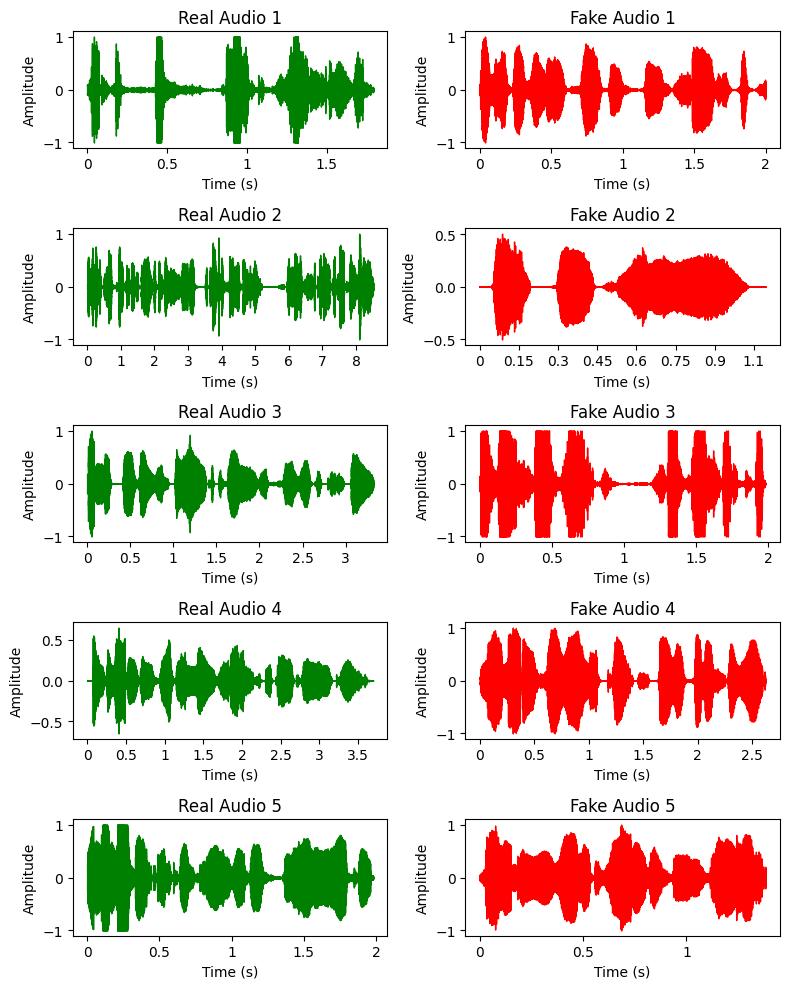

In [44]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
import random

# Ensure GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f"⚠️ {e}")
    print("✅ GPU is available and configured.")

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/'},
    {'name': 'for-norm', 'path': '/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/'},
    {'name': 'for-original', 'path': '/kaggle/input/the-fake-or-real-dataset/for-original/for-original/'},
    {'name': 'for-rerec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/'},
]

# Function to load and visualize 5 random sample waveforms from "real" and "fake" categories
def visualize_waveform():
    real_samples = []
    fake_samples = []

    for dataset in datasets:
        for split in ['training', 'validation', 'testing']:
            for label in ['fake', 'real']:
                label_path = os.path.join(dataset['path'], split, label)
                files = [f for f in os.listdir(label_path) if f.endswith('.wav')]
                if files:
                    sample_file = os.path.join(label_path, random.choice(files))
                    if label == 'real':
                        real_samples.append((dataset['name'], split, label, sample_file))
                    else:
                        fake_samples.append((dataset['name'], split, label, sample_file))

    random.shuffle(real_samples)
    random.shuffle(fake_samples)

    plt.figure(figsize=(8, 10))

    for i in range(5):
        # Plot real audio
        if i < len(real_samples):
            dataset_name, split, label, sample_file = real_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)

            plt.subplot(5, 2, 2 * i + 1)
            librosa.display.waveshow(audio, sr=sr, color='green')
            plt.title(f"Real Audio {i + 1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")

        # Plot fake audio
        if i < len(fake_samples):
            dataset_name, split, label, sample_file = fake_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)

            plt.subplot(5, 2, 2 * i + 2)
            librosa.display.waveshow(audio, sr=sr, color='red')
            plt.title(f"Fake Audio {i + 1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

visualize_waveform()

⚠️ Physical devices cannot be modified after being initialized
⚠️ Physical devices cannot be modified after being initialized
✅ GPU is available and configured.


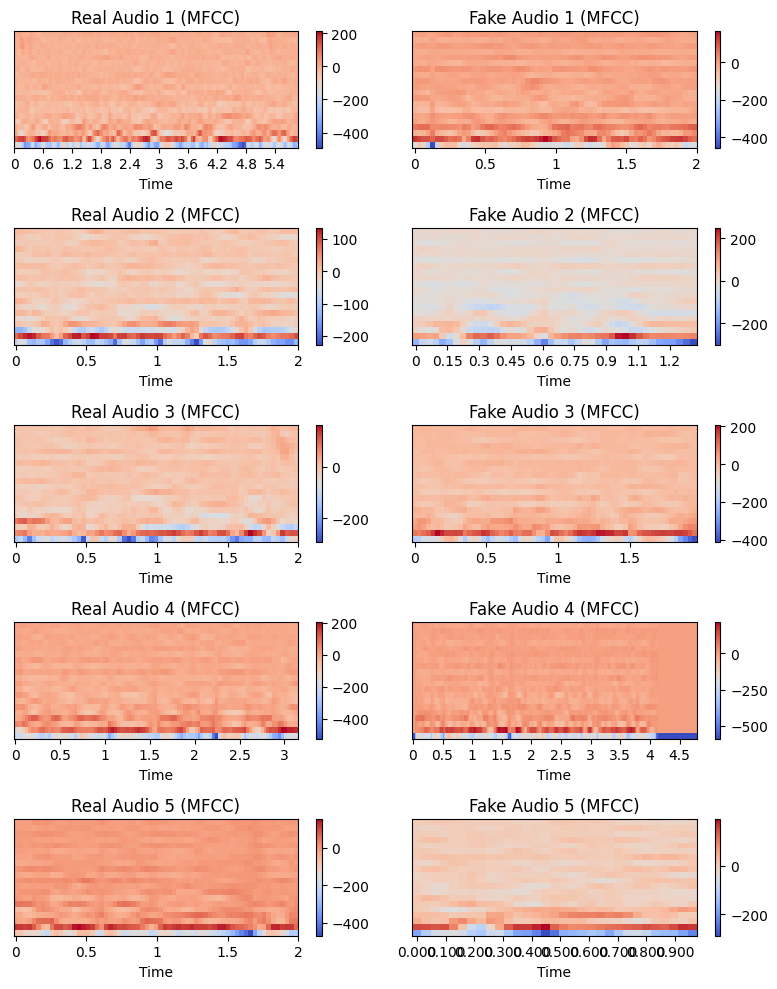

In [45]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
import random

# Ensure GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f"⚠️ {e}")
    print("✅ GPU is available and configured.")

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/'},
    {'name': 'for-norm', 'path': '/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/'},
    {'name': 'for-original', 'path': '/kaggle/input/the-fake-or-real-dataset/for-original/for-original/'},
    {'name': 'for-rerec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/'},
]

# Function to load and visualize 5 random sample MFCCs from "real" and "fake" categories
def visualize_mfcc():
    real_samples = []
    fake_samples = []

    for dataset in datasets:
        for split in ['training', 'validation', 'testing']:
            for label in ['fake', 'real']:
                label_path = os.path.join(dataset['path'], split, label)
                files = [f for f in os.listdir(label_path) if f.endswith('.wav')]
                if files:
                    sample_file = os.path.join(label_path, random.choice(files))
                    if label == 'real':
                        real_samples.append((dataset['name'], split, label, sample_file))
                    else:
                        fake_samples.append((dataset['name'], split, label, sample_file))

    random.shuffle(real_samples)
    random.shuffle(fake_samples)

    plt.figure(figsize=(8, 10))

    for i in range(5):
        # Plot real audio MFCC
        if i < len(real_samples):
            dataset_name, split, label, sample_file = real_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

            plt.subplot(5, 2, 2 * i + 1)
            librosa.display.specshow(mfcc, sr=sr, x_axis='time')
            plt.colorbar()
            plt.title(f"Real Audio {i + 1} (MFCC)")

        # Plot fake audio MFCC
        if i < len(fake_samples):
            dataset_name, split, label, sample_file = fake_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

            plt.subplot(5, 2, 2 * i + 2)
            librosa.display.specshow(mfcc, sr=sr, x_axis='time')
            plt.colorbar()
            plt.title(f"Fake Audio {i + 1} (MFCC)")

    plt.tight_layout()
    plt.show()

visualize_mfcc()

⚠️ Physical devices cannot be modified after being initialized
⚠️ Physical devices cannot be modified after being initialized
✅ GPU is available and configured.


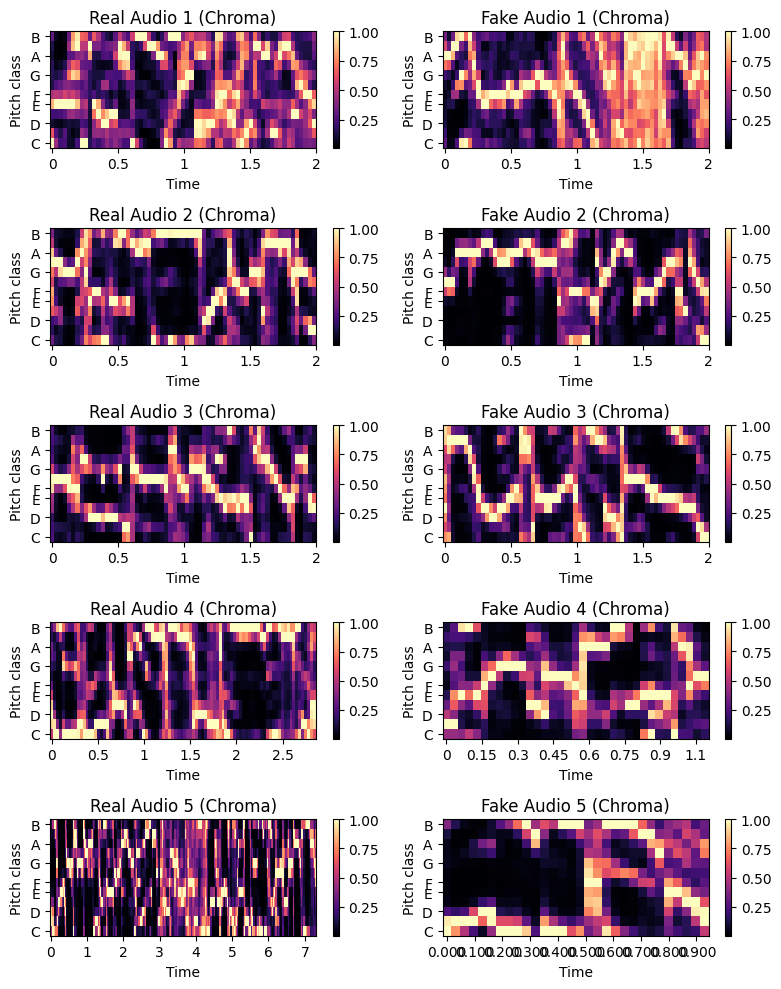

In [47]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
import random

# Ensure GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f"⚠️ {e}")
    print("✅ GPU is available and configured.")

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/'},
    {'name': 'for-norm', 'path': '/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/'},
    {'name': 'for-original', 'path': '/kaggle/input/the-fake-or-real-dataset/for-original/for-original/'},
    {'name': 'for-rerec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/'},
]

# Function to load and visualize chroma features of "real" and "fake" audio
def visualize_chroma_features():
    real_chroma = []
    fake_chroma = []

    for dataset in datasets:
        for split in ['training', 'validation', 'testing']:
            for label in ['fake', 'real']:
                label_path = os.path.join(dataset['path'], split, label)
                files = [f for f in os.listdir(label_path) if f.endswith('.wav')]
                if files:
                    sample_file = os.path.join(label_path, random.choice(files))
                    audio, sr = librosa.load(sample_file, sr=None)
                    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
                    if label == 'real':
                        real_chroma.append(chroma)
                    else:
                        fake_chroma.append(chroma)

    plt.figure(figsize=(8, 10))

    for i in range(5):
        # Plot real audio chroma
        plt.subplot(5, 2, 2 * i + 1)
        librosa.display.specshow(real_chroma[i], sr=sr, x_axis='time', y_axis='chroma')
        plt.colorbar()
        plt.title(f"Real Audio {i + 1} (Chroma)")

        # Plot fake audio chroma
        plt.subplot(5, 2, 2 * i + 2)
        librosa.display.specshow(fake_chroma[i], sr=sr, x_axis='time', y_axis='chroma')
        plt.colorbar()
        plt.title(f"Fake Audio {i + 1} (Chroma)")

    plt.tight_layout()
    plt.show()

visualize_chroma_features()

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# ✅ Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-2sec/for-2seconds/"

# ✅ Fixed Feature Shape
FIXED_HEIGHT = 64
FIXED_WIDTH = 94

# ✅ Load Features & Labels
def load_features_and_labels(dataset_path):
    features, labels = [], []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")

                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize Features
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))

# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Reshape for LSTM (Time Steps, Features)
X_train = X_train.reshape(X_train.shape[0], FIXED_WIDTH, -1)
X_test = X_test.reshape(X_test.shape[0], FIXED_WIDTH, -1)

# ✅ Define LSTM Model
model = keras.Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(128, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax')
])

# ✅ Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audio_lstm_modell.h5")
print("✅ LSTM Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy

# ✅ Print Metrics
print("\n=== LSTM Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.5710 - loss: 0.8477 - val_accuracy: 0.6575 - val_loss: 0.6335 - learning_rate: 0.0010
Epoch 2/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7559 - loss: 0.4954 - val_accuracy: 0.7017 - val_loss: 0.5372 - learning_rate: 0.0010
Epoch 3/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8378 - loss: 0.3590 - val_accuracy: 0.7974 - val_loss: 0.4717 - learning_rate: 0.0010
Epoch 4/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9089 - loss: 0.2279 - val_accuracy: 0.8414 - val_loss: 0.3474 - learning_rate: 0.0010
Epoch 5/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9382 - loss: 0.1556 - val_accuracy: 0.6760 - val_loss: 1.2460 - learning_rate: 0.0010
Epoch 6/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9473 - loss: 0.1351 - val_accuracy: 0.9037 - val_loss: 0.2231 - learning_rate: 0.0010
Epoch 7/30
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9593 - l

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# ✅ Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-norm/for-norm/"

# ✅ Fixed Feature Shape
FIXED_HEIGHT = 64
FIXED_WIDTH = 94

# ✅ Load Features & Labels
def load_features_and_labels(dataset_path):
    features, labels = [], []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")

                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize Features
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))

# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Reshape for LSTM (Time Steps, Features)
X_train = X_train.reshape(X_train.shape[0], FIXED_WIDTH, -1)
X_test = X_test.reshape(X_test.shape[0], FIXED_WIDTH, -1)

# ✅ Define LSTM Model
model = keras.Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(128, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax')
])

# ✅ Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audioo_lstm_model.h5")
print("✅ LSTM Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy

# ✅ Print Metrics
print("\n=== LSTM Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.8115 - loss: 0.4562 - val_accuracy: 0.5073 - val_loss: 1.6296 - learning_rate: 0.0010
Epoch 2/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9083 - loss: 0.2362 - val_accuracy: 0.9113 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 3/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9523 - loss: 0.1340 - val_accuracy: 0.9227 - val_loss: 0.2054 - learning_rate: 0.0010
Epoch 4/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9635 - loss: 0.1030 - val_accuracy: 0.8656 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 5/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9701 - loss: 0.0870 - val_accuracy: 0.7475 - val_loss: 0.9127 - learning_rate: 0.0010
Epoch 6/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9761 - loss: 0.0709 - val_accuracy: 0.9763 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 7/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accura

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# ✅ Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-original/for-original/"

# ✅ Fixed Feature Shape
FIXED_HEIGHT = 64
FIXED_WIDTH = 94

# ✅ Load Features & Labels
def load_features_and_labels(dataset_path):
    features, labels = [], []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")

                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize Features
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))

# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Reshape for LSTM (Time Steps, Features)
X_train = X_train.reshape(X_train.shape[0], FIXED_WIDTH, -1)
X_test = X_test.reshape(X_test.shape[0], FIXED_WIDTH, -1)

# ✅ Define LSTM Model
model = keras.Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(128, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax')
])

# ✅ Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deeepfake_audio_lstm_model.h5")
print("✅ LSTM Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy

# ✅ Print Metrics
print("\n=== LSTM Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.8922 - loss: 0.2816 - val_accuracy: 0.9285 - val_loss: 0.1725 - learning_rate: 0.0010
Epoch 2/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step - accuracy: 0.9661 - loss: 0.0939 - val_accuracy: 0.9257 - val_loss: 0.2517 - learning_rate: 0.0010
Epoch 3/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9742 - loss: 0.0735 - val_accuracy: 0.9750 - val_loss: 0.0707 - learning_rate: 0.0010
Epoch 4/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9820 - loss: 0.0522 - val_accuracy: 0.9815 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 5/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9881 - loss: 0.0356 - val_accuracy: 0.9838 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 6/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9894 - loss: 0.0299 - val_accuracy: 0.9719 - val_loss: 0.0802 - learning_rate: 0.0010
Epoch 7/30
1733/1733 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accura

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

# ✅ Dataset Path
DATASET_PATH = "/kaggle/working/cleaned_audio/for-rerec/for-rerecorded/"

# ✅ Fixed Feature Shape
FIXED_HEIGHT = 64
FIXED_WIDTH = 94

# ✅ Load Features & Labels
def load_features_and_labels(dataset_path):
    features, labels = [], []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.endswith("_mel.npy"):
                mel_path = os.path.join(root, file)
                mfcc_path = mel_path.replace("_mel.npy", "_mfcc.npy")

                if os.path.exists(mfcc_path):
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    mel_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))
                    mfcc_resized = np.zeros((FIXED_HEIGHT, FIXED_WIDTH))

                    mel_resized[:mel.shape[0], :mel.shape[1]] = mel[:FIXED_HEIGHT, :FIXED_WIDTH]
                    mfcc_resized[:mfcc.shape[0], :mfcc.shape[1]] = mfcc[:FIXED_HEIGHT, :FIXED_WIDTH]

                    combined_features = np.stack((mel_resized, mfcc_resized), axis=-1)
                    features.append(combined_features)
                    labels.append(os.path.basename(root))

    return np.array(features, dtype=np.float32), np.array(labels, dtype=str)

X, y = load_features_and_labels(DATASET_PATH)

# ✅ Normalize Features
X = np.nan_to_num(X / (np.max(np.abs(X), axis=(0, 1, 2), keepdims=True) + 1e-8))

# ✅ Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Reshape for LSTM (Time Steps, Features)
X_train = X_train.reshape(X_train.shape[0], FIXED_WIDTH, -1)
X_test = X_test.reshape(X_test.shape[0], FIXED_WIDTH, -1)

# ✅ Define LSTM Model
model = keras.Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(128, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax')
])

# ✅ Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ✅ Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# ✅ Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

# ✅ Save Model
model.save("/kaggle/working/deepfakee_audio_lstm_model.h5")
print("✅ LSTM Model saved successfully!")

# ✅ Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_pred_probs)

test_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
equal_error_rate = 1 - accuracy

# ✅ Print Metrics
print("\n=== LSTM Model Evaluation Metrics ===")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1 Score: {f1:.4f}")
print(f"5. Log Loss: {logloss:.4f}")
print(f"6. Testing Accuracy: {test_accuracy:.4f}")
print(f"7. Validation Accuracy: {val_accuracy:.4f}")
print(f"8. Equal Error Rate (EER): {equal_error_rate:.4f}")


Epoch 1/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.5463 - loss: 0.9266 - val_accuracy: 0.5015 - val_loss: 0.8961 - learning_rate: 0.0010
Epoch 2/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7081 - loss: 0.5753 - val_accuracy: 0.7321 - val_loss: 0.6033 - learning_rate: 0.0010
Epoch 3/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7713 - loss: 0.4951 - val_accuracy: 0.5015 - val_loss: 3.1715 - learning_rate: 0.0010
Epoch 4/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8085 - loss: 0.4336 - val_accuracy: 0.5019 - val_loss: 1.6348 - learning_rate: 0.0010
Epoch 5/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8169 - loss: 0.4044 - val_accuracy: 0.7931 - val_loss: 0.4354 - learning_rate: 0.0010
Epoch 6/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8294 - loss: 0.3784 - val_accuracy: 0.5354 - val_loss: 1.3262 - learning_rate: 0.0010
Epoch 7/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8302 - loss: 0

In [10]:
#CNN MODEL
import pandas as pd
from tabulate import tabulate

data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Testing Accuracy', 'Validation Accuracy', 'AUC-ROC', 'Log Loss', 'EER'],
    'For-2sec': [0.752577, 0.717908, 0.832721, 0.771064, 0.993623, 0.978769, 0.857740, 0.715321, 0.142260],
    'For-Norm': [0.928356, 0.970302, 0.883000, 0.923113, 0.997364, 0.985090, 0.983156, 0.220151, 0.016844],
    'For-Original': [0.859085, 0.778816, 0.993816, 0.873278, 0.998775, 0.996573, 0.989101, 0.543165, 0.010899],
    'For-Rerec': [0.598039, 0.555710, 0.977941, 0.708703, 0.981289, 0.892603, 0.808848, 2.175234, 0.191152]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

| Metric              |   For-2sec |   For-Norm |   For-Original |   For-Rerec |
|---------------------|------------|------------|----------------|-------------|
| Accuracy            |   0.752577 |   0.928356 |       0.859085 |    0.598039 |
| Precision           |   0.717908 |   0.970302 |       0.778816 |    0.55571  |
| Recall              |   0.832721 |   0.883    |       0.993816 |    0.977941 |
| F1 Score            |   0.771064 |   0.923113 |       0.873278 |    0.708703 |
| Testing Accuracy    |   0.993623 |   0.997364 |       0.998775 |    0.981289 |
| Validation Accuracy |   0.978769 |   0.98509  |       0.996573 |    0.892603 |
| AUC-ROC             |   0.85774  |   0.983156 |       0.989101 |    0.808848 |
| Log Loss            |   0.715321 |   0.220151 |       0.543165 |    2.17523  |
| EER                 |   0.14226  |   0.016844 |       0.010899 |    0.191152 |


In [5]:
#RNN MODEL
import pandas as pd
from tabulate import tabulate

# Data for the table
data = {
    'Metric': [
        'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Testing Accuracy',
        'Validation Accuracy', 'AUC-ROC', 'Log Loss', 'EER'
    ],
    'For-2sec': [
        0.608456, 0.606115, 0.619485, 0.612727, 0.712670,
        0.939137, 0.633248, 1.138292, 0.366752
    ],
    'For-Norm': [
        0.771472, 0.728479, 0.844898, 0.783922, 0.982717,
        0.964808, 0.855257, 0.731820, 0.144743
    ],
    'For-Original': [
        0.814631, 0.780663, 0.863074, 0.819803, 0.995563,
        0.993425, 0.896466, 0.689669, 0.103534
    ],
    'For-Rerec': [
        0.650735, 0.651852, 0.647059, 0.649446, 0.887539,
        0.811497, 0.708869, 0.806532, 0.299131
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))


| Metric              |   For-2sec |   For-Norm |   For-Original |   For-Rerec |
|---------------------|------------|------------|----------------|-------------|
| Accuracy            |   0.608456 |   0.771472 |       0.814631 |    0.650735 |
| Precision           |   0.606115 |   0.728479 |       0.780663 |    0.651852 |
| Recall              |   0.619485 |   0.844898 |       0.863074 |    0.647059 |
| F1 Score            |   0.612727 |   0.783922 |       0.819803 |    0.649446 |
| Testing Accuracy    |   0.71267  |   0.982717 |       0.995563 |    0.887539 |
| Validation Accuracy |   0.939137 |   0.964808 |       0.993425 |    0.811497 |
| AUC-ROC             |   0.633248 |   0.855257 |       0.896466 |    0.708869 |
| Log Loss            |   1.13829  |   0.73182  |       0.689669 |    0.806532 |
| EER                 |   0.366752 |   0.144743 |       0.103534 |    0.299131 |


In [6]:
#CNN+LSTM(CRNN)
import pandas as pd
from tabulate import tabulate

# Data for the table
data = {
    'Metric': [
        'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Testing Accuracy',
        'Validation Accuracy', 'AUC-ROC', 'Log Loss', 'Equal Error Rate (EER)'
    ],
    'For-2sec': [
        0.9966, 0.9966, 0.9966, 0.9966, 0.9995,
        0.9950, 0.9966, 0.0093, 0.0034
    ],
    'For-Norm': [
        0.9991, 0.9991, 0.9991, 0.9991, 0.9997,
        0.9983, 0.9991, 0.0026, 0.0009
    ],
    'For-Original': [
        0.9991, 0.9991, 0.9991, 0.9991, 0.9995,
        0.9986, 0.9991, 0.0028, 0.0009
    ],
    'For-Rerec': [
        0.9902, 0.9902, 0.9902, 0.9902, 0.9997,
        0.9680, 0.9902, 0.0361, 0.0098
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

| Metric                 |   For-2sec |   For-Norm |   For-Original |   For-Rerec |
|------------------------|------------|------------|----------------|-------------|
| Accuracy               |     0.9966 |     0.9991 |         0.9991 |      0.9902 |
| Precision              |     0.9966 |     0.9991 |         0.9991 |      0.9902 |
| Recall                 |     0.9966 |     0.9991 |         0.9991 |      0.9902 |
| F1 Score               |     0.9966 |     0.9991 |         0.9991 |      0.9902 |
| Testing Accuracy       |     0.9995 |     0.9997 |         0.9995 |      0.9997 |
| Validation Accuracy    |     0.995  |     0.9983 |         0.9986 |      0.968  |
| AUC-ROC                |     0.9966 |     0.9991 |         0.9991 |      0.9902 |
| Log Loss               |     0.0093 |     0.0026 |         0.0028 |      0.0361 |
| Equal Error Rate (EER) |     0.0034 |     0.0009 |         0.0009 |      0.0098 |


In [11]:
#CNN+RNN
import pandas as pd
from tabulate import tabulate

data = {
    'Metric': [
        'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Testing Accuracy',
        'Validation Accuracy', 'AUC-ROC', 'Log Loss', 'Equal Error Rate (EER)'
    ],
    'For-2sec': [
        0.647978, 0.655706, 0.623162, 0.639020, 0.985813,
        0.933475, 0.703882, 1.104656, 0.296118
    ],
    'For-Norm': [
        0.6940, 0.6283, 0.5152, 0.7451, 0.9945,
        0.9888, 0.8588, 1.0154, 0.1412
    ],
    'For-Original': [
        0.7164, 0.6439, 0.9386, 0.7638, 0.9972,
        0.9772, 0.8731, 1.2431, 0.1268
    ],
    'For-Rerec': [
        0.5061, 0.5040, 0.7696, 0.6991, 0.9397,
        0.8707, 0.6232, 1.4255, 0.3768
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

| Metric                 |   For-2sec |   For-Norm |   For-Original |   For-Rerec |
|------------------------|------------|------------|----------------|-------------|
| Accuracy               |   0.647978 |     0.694  |         0.7164 |      0.5061 |
| Precision              |   0.655706 |     0.6283 |         0.6439 |      0.504  |
| Recall                 |   0.623162 |     0.5152 |         0.9386 |      0.7696 |
| F1 Score               |   0.63902  |     0.7451 |         0.7638 |      0.6991 |
| Testing Accuracy       |   0.985813 |     0.9945 |         0.9972 |      0.9397 |
| Validation Accuracy    |   0.933475 |     0.9888 |         0.9772 |      0.8707 |
| AUC-ROC                |   0.703882 |     0.8588 |         0.8731 |      0.6232 |
| Log Loss               |   1.10466  |     1.0154 |         1.2431 |      1.4255 |
| Equal Error Rate (EER) |   0.296118 |     0.1412 |         0.1268 |      0.3768 |


In [12]:
#LSTM
import pandas as pd
from tabulate import tabulate

# Create the table data
data = {
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1 Score",
        "Testing Accuracy", "Validation Accuracy", "AUC-ROC",
        "Log Loss", "Equal Error Rate (EER)"
    ],
    "For-2sec": [0.9888, 0.9888, 0.9888, 0.9888, 0.9922, 0.9787, 0.9890, 0.0324, 0.0112],
    "For-Norm": [0.9961, 0.9961, 0.9961, 0.9961, 0.9968, 0.9967, 0.9970, 0.0106, 0.0039],
    "For-Original": [0.9991, 0.9991, 0.9991, 0.9991, 0.9989, 0.9987, 0.9990, 0.0024, 0.0009],
    "For-Rerec": [0.9555, 0.9560, 0.9555, 0.9555, 0.9732, 0.9047, 0.9740, 0.1294, 0.0445]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

| Metric                 |   For-2sec |   For-Norm |   For-Original |   For-Rerec |
|------------------------|------------|------------|----------------|-------------|
| Accuracy               |     0.9888 |     0.9961 |         0.9991 |      0.9555 |
| Precision              |     0.9888 |     0.9961 |         0.9991 |      0.956  |
| Recall                 |     0.9888 |     0.9961 |         0.9991 |      0.9555 |
| F1 Score               |     0.9888 |     0.9961 |         0.9991 |      0.9555 |
| Testing Accuracy       |     0.9922 |     0.9968 |         0.9989 |      0.9732 |
| Validation Accuracy    |     0.9787 |     0.9967 |         0.9987 |      0.9047 |
| AUC-ROC                |     0.989  |     0.997  |         0.999  |      0.974  |
| Log Loss               |     0.0324 |     0.0106 |         0.0024 |      0.1294 |
| Equal Error Rate (EER) |     0.0112 |     0.0039 |         0.0009 |      0.0445 |


In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, log_loss
from tensorflow.keras.callbacks import ModelCheckpoint
from tqdm import tqdm
from tabulate import tabulate

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/working/cleaned_audio/for-2sec/for-2seconds/'}
]

# ✅ Load dataset
def load_data(base_path):
    def load_features(folder):
        X, y = [], []
        for label in ['fake', 'real']:
            folder_path = os.path.join(base_path, folder, label)
            for file in tqdm(os.listdir(folder_path), desc=f"Loading {label} data"):
                if file.endswith('_mel.npy'):
                    mel_path = os.path.join(folder_path, file)
                    mfcc_path = mel_path.replace('_mel.npy', '_mfcc.npy')
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    # Ensure consistent shape
                    min_shape = (min(mel.shape[0], mfcc.shape[0]), min(mel.shape[1], mfcc.shape[1]))
                    mel = mel[:min_shape[0], :min_shape[1]]
                    mfcc = mfcc[:min_shape[0], :min_shape[1]]

                    combined = np.stack((mel, mfcc), axis=-1)  # Ensure 4D shape
                    X.append(combined)
                    y.append(0 if label == 'fake' else 1)
        return np.array(X), np.array(y)

    X_train, y_train = load_features('training')
    X_val, y_val = load_features('validation')
    X_test, y_test = load_features('testing')

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ✅ Transformer model
def build_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Reshape((-1, x.shape[-1]))(x)

    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ✅ Calculate EER
def calculate_eer(y_true, y_scores):
    from scipy.optimize import brentq
    from scipy.interpolate import interp1d
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_threshold = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    eer = interp1d(fpr, thresholds)(eer_threshold)
    return eer_threshold

# ✅ Training and evaluation
def train_and_evaluate(dataset):
    print(f"🚀 Training on dataset: {dataset['name']}")

    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data(dataset['path'])

    model = build_transformer(X_train.shape[1:])

    checkpoint_path = f"/kaggle/working/{dataset['name']}_best_model.keras"
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    eer = calculate_eer(y_test, y_pred_probs)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Testing Accuracy": accuracy_score(y_test, y_pred),
        "Validation Accuracy": val_acc,
        "AUC-ROC": roc_auc_score(y_test, y_pred_probs),
        "Log Loss": log_loss(y_test, y_pred_probs),
        "Equal Error Rate (EER)": eer
    }

    # ✅ Display evaluation metrics as a table
    data = {
        "Metric": list(metrics.keys()),
        dataset["name"]: [f"{value:.4f}" for value in metrics.values()]
    }

    df = pd.DataFrame(data)
    print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print(f"✅ Model saved to: {checkpoint_path}")

# ✅ Run training for each dataset
for dataset in datasets:
    train_and_evaluate(dataset)

# ✅ Save Model
model.save("/kaggle/working/deepfake_audio_transformer_model.keras")
print("✅ Transformer Model saved successfully!")


🚀 Training on dataset: for-2sec


Loading real data: 100%|██████████| 1088/1088 [00:00<00:00, 8263.07it/s]


Epoch 1/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8364 - loss: 0.3475 - val_accuracy: 0.9628 - val_loss: 0.1060
Epoch 2/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9676 - loss: 0.0900 - val_accuracy: 0.9791 - val_loss: 0.0685
Epoch 3/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9743 - loss: 0.0741 - val_accuracy: 0.9830 - val_loss: 0.0454
Epoch 4/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9825 - loss: 0.0488 - val_accuracy: 0.9805 - val_loss: 0.0835
Epoch 5/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9812 - loss: 0.0548 - val_accuracy: 0.9738 - val_loss: 0.0866
Epoch 6/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9915 - val_loss: 0.0265
Epoch 7/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9884 - loss: 0.0311 - val_accuracy: 0.9696 - val_loss: 0.0754
Epoch 8/30
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9904 - loss: 0.0274 - val_accuracy: 

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, log_loss
from tensorflow.keras.callbacks import ModelCheckpoint
from tqdm import tqdm
from tabulate import tabulate

# ✅ Dataset paths
datasets = [
    {'name': 'for-norm', 'path': '/kaggle/working/cleaned_audio/for-norm/for-norm/'}
]

# ✅ Load dataset
def load_data(base_path):
    def load_features(folder):
        X, y = [], []
        for label in ['fake', 'real']:
            folder_path = os.path.join(base_path, folder, label)
            for file in tqdm(os.listdir(folder_path), desc=f"Loading {label} data"):
                if file.endswith('_mel.npy'):
                    mel_path = os.path.join(folder_path, file)
                    mfcc_path = mel_path.replace('_mel.npy', '_mfcc.npy')
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    # Ensure consistent shape
                    min_shape = (min(mel.shape[0], mfcc.shape[0]), min(mel.shape[1], mfcc.shape[1]))
                    mel = mel[:min_shape[0], :min_shape[1]]
                    mfcc = mfcc[:min_shape[0], :min_shape[1]]

                    combined = np.stack((mel, mfcc), axis=-1)  # Ensure 4D shape
                    X.append(combined)
                    y.append(0 if label == 'fake' else 1)
        return np.array(X), np.array(y)

    X_train, y_train = load_features('training')
    X_val, y_val = load_features('validation')
    X_test, y_test = load_features('testing')

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ✅ Transformer model
def build_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Reshape((-1, x.shape[-1]))(x)

    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
# ✅ Calculate EER
def calculate_eer(y_true, y_scores):
    from scipy.optimize import brentq
    from scipy.interpolate import interp1d
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_threshold = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    eer = interp1d(fpr, thresholds)(eer_threshold)
    return eer_threshold

# ✅ Training and evaluation
def train_and_evaluate(dataset):
    print(f"🚀 Training on dataset: {dataset['name']}")

    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data(dataset['path'])

    model = build_transformer(X_train.shape[1:])

    checkpoint_path = f"/kaggle/working/{dataset['name']}_best_model.keras"
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    eer = calculate_eer(y_test, y_pred_probs)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Testing Accuracy": accuracy_score(y_test, y_pred),
        "Validation Accuracy": val_acc,
        "AUC-ROC": roc_auc_score(y_test, y_pred_probs),
        "Log Loss": log_loss(y_test, y_pred_probs),
        "Equal Error Rate (EER)": eer
    }

    # ✅ Display evaluation metrics as a table
    data = {
        "Metric": list(metrics.keys()),
        dataset["name"]: [f"{value:.4f}" for value in metrics.values()]
    }

    df = pd.DataFrame(data)
    print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print(f"✅ Model saved to: {checkpoint_path}")

# ✅ Run training for each dataset
for dataset in datasets:
    train_and_evaluate(dataset)

# ✅ Save Model
model.save("/kaggle/working/deeepfake_audio_transformer_model.keras")
print("✅ Transformer Model saved successfully!")


🚀 Training on dataset: for-norm


Loading real data: 100%|██████████| 4528/4528 [00:00<00:00, 8352.72it/s]


Epoch 1/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9277 - loss: 0.1824 - val_accuracy: 0.9806 - val_loss: 0.0555
Epoch 2/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9805 - loss: 0.0559 - val_accuracy: 0.9824 - val_loss: 0.0524
Epoch 3/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9872 - loss: 0.0396 - val_accuracy: 0.9926 - val_loss: 0.0231
Epoch 4/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9897 - loss: 0.0324 - val_accuracy: 0.9684 - val_loss: 0.0839
Epoch 5/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9911 - loss: 0.0271 - val_accuracy: 0.9920 - val_loss: 0.0251
Epoch 6/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9924 - loss: 0.0238 - val_accuracy: 0.9816 - val_loss: 0.0586
Epoch 7/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.0234 - val_accuracy: 0.9919 - val_loss: 0.0263
Epoch 8/30
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.0217 -

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, log_loss
from tensorflow.keras.callbacks import ModelCheckpoint
from tqdm import tqdm
from tabulate import tabulate

# ✅ Dataset paths
datasets = [
    {'name': 'for-original', 'path': '/kaggle/working/cleaned_audio/for-original/for-original/'}
]

# ✅ Load dataset
def load_data(base_path):
    def load_features(folder):
        X, y = [], []
        for label in ['fake', 'real']:
            folder_path = os.path.join(base_path, folder, label)
            for file in tqdm(os.listdir(folder_path), desc=f"Loading {label} data"):
                if file.endswith('_mel.npy'):
                    mel_path = os.path.join(folder_path, file)
                    mfcc_path = mel_path.replace('_mel.npy', '_mfcc.npy')
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    # Ensure consistent shape
                    min_shape = (min(mel.shape[0], mfcc.shape[0]), min(mel.shape[1], mfcc.shape[1]))
                    mel = mel[:min_shape[0], :min_shape[1]]
                    mfcc = mfcc[:min_shape[0], :min_shape[1]]

                    combined = np.stack((mel, mfcc), axis=-1)  # Ensure 4D shape
                    X.append(combined)
                    y.append(0 if label == 'fake' else 1)
        return np.array(X), np.array(y)

    X_train, y_train = load_features('training')
    X_val, y_val = load_features('validation')
    X_test, y_test = load_features('testing')

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ✅ Transformer model
def build_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Reshape((-1, x.shape[-1]))(x)

    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
# ✅ Calculate EER
def calculate_eer(y_true, y_scores):
    from scipy.optimize import brentq
    from scipy.interpolate import interp1d
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_threshold = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    eer = interp1d(fpr, thresholds)(eer_threshold)
    return eer_threshold

# ✅ Training and evaluation
def train_and_evaluate(dataset):
    print(f"🚀 Training on dataset: {dataset['name']}")
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data(dataset['path'])

    model = build_transformer(X_train.shape[1:])

    checkpoint_path = f"/kaggle/working/{dataset['name']}_best_model.keras"
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()


    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    eer = calculate_eer(y_test, y_pred_probs)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Testing Accuracy": accuracy_score(y_test, y_pred),
        "Validation Accuracy": val_acc,
        "AUC-ROC": roc_auc_score(y_test, y_pred_probs),
        "Log Loss": log_loss(y_test, y_pred_probs),
        "Equal Error Rate (EER)": eer
    }

    # ✅ Display evaluation metrics as a table
    data = {
        "Metric": list(metrics.keys()),
        dataset["name"]: [f"{value:.4f}" for value in metrics.values()]
    }

    df = pd.DataFrame(data)
    print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print(f"✅ Model saved to: {checkpoint_path}")

# ✅ Run training for each dataset
for dataset in datasets:
    train_and_evaluate(dataset)

# ✅ Save Model
model.save("/kaggle/working/deeepfake_audiio_transformer_model.keras")
print("✅ Transformer Model saved successfully!")


🚀 Training on dataset: for-original


Loading real data: 100%|██████████| 4528/4528 [00:00<00:00, 8459.24it/s]


Epoch 1/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.9510 - loss: 0.1195 - val_accuracy: 0.9950 - val_loss: 0.0155
Epoch 2/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9944 - loss: 0.0176 - val_accuracy: 0.9993 - val_loss: 0.0033
Epoch 3/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9967 - loss: 0.0120 - val_accuracy: 0.9931 - val_loss: 0.0175
Epoch 4/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9944 - loss: 0.0183 - val_accuracy: 0.9989 - val_loss: 0.0036
Epoch 5/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9964 - loss: 0.0113 - val_accuracy: 0.9951 - val_loss: 0.0146
Epoch 6/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9980 - loss: 0.0065 - val_accuracy: 0.9957 - val_loss: 0.0114
Epoch 7/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9941 - loss: 0.0200 - val_accuracy: 0.9981 - val_loss: 0.0088
Epoch 8/30
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9970 - loss: 0.0106 -

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, log_loss
from tensorflow.keras.callbacks import ModelCheckpoint
from tqdm import tqdm
from tabulate import tabulate

# ✅ Dataset paths
datasets = [
    {'name': 'for-rerec', 'path': '/kaggle/working/cleaned_audio/for-rerec/for-rerecorded/'}
]
# ✅ Load dataset
def load_data(base_path):
    def load_features(folder):
        X, y = [], []
        for label in ['fake', 'real']:
            folder_path = os.path.join(base_path, folder, label)
            for file in tqdm(os.listdir(folder_path), desc=f"Loading {label} data"):
                if file.endswith('_mel.npy'):
                    mel_path = os.path.join(folder_path, file)
                    mfcc_path = mel_path.replace('_mel.npy', '_mfcc.npy')
                    mel = np.load(mel_path)
                    mfcc = np.load(mfcc_path)

                    # Ensure consistent shape
                    min_shape = (min(mel.shape[0], mfcc.shape[0]), min(mel.shape[1], mfcc.shape[1]))
                    mel = mel[:min_shape[0], :min_shape[1]]
                    mfcc = mfcc[:min_shape[0], :min_shape[1]]

                    combined = np.stack((mel, mfcc), axis=-1)  # Ensure 4D shape
                    X.append(combined)
                    y.append(0 if label == 'fake' else 1)
        return np.array(X), np.array(y)

    X_train, y_train = load_features('training')
    X_val, y_val = load_features('validation')
    X_test, y_test = load_features('testing')

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ✅ Transformer model
def build_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Reshape((-1, x.shape[-1]))(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
# ✅ Calculate EER
def calculate_eer(y_true, y_scores):
    from scipy.optimize import brentq
    from scipy.interpolate import interp1d
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_threshold = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    eer = interp1d(fpr, thresholds)(eer_threshold)
    return eer_threshold

# ✅ Training and evaluation
def train_and_evaluate(dataset):
    print(f"🚀 Training on dataset: {dataset['name']}")
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data(dataset['path'])

    model = build_transformer(X_train.shape[1:])


    checkpoint_path = f"/kaggle/working/{dataset['name']}_best_model.keras"
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()


    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    eer = calculate_eer(y_test, y_pred_probs)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Testing Accuracy": accuracy_score(y_test, y_pred),
        "Validation Accuracy": val_acc,
        "AUC-ROC": roc_auc_score(y_test, y_pred_probs),
        "Log Loss": log_loss(y_test, y_pred_probs),
        "Equal Error Rate (EER)": eer
    }

    # ✅ Display evaluation metrics as a table
    data = {
        "Metric": list(metrics.keys()),
        dataset["name"]: [f"{value:.4f}" for value in metrics.values()]
    }

    df = pd.DataFrame(data)
    print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print(f"✅ Model saved to: {checkpoint_path}")

# ✅ Run training for each dataset
for dataset in datasets:
    train_and_evaluate(dataset)

# ✅ Save Model
model.save("/kaggle/working/deeepfake_audiio_trransformer_modell.keras")
print("✅ Transformer Model saved successfully!")

🚀 Training on dataset: for-rerec


Loading real data: 100%|██████████| 816/816 [00:00<00:00, 8419.23it/s]


Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7535 - loss: 0.4938 - val_accuracy: 0.9300 - val_loss: 0.1653
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9449 - loss: 0.1542 - val_accuracy: 0.9617 - val_loss: 0.1082
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9620 - loss: 0.1081 - val_accuracy: 0.9416 - val_loss: 0.1443
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9756 - loss: 0.0787 - val_accuracy: 0.9635 - val_loss: 0.1175
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9700 - loss: 0.0803 - val_accuracy: 0.9675 - val_loss: 0.0903
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9785 - loss: 0.0586 - val_accuracy: 0.9416 - val_loss: 0.1584
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9820 - loss: 0.0553 - val_accuracy: 0.8111 - val_loss: 0.5703
Epoch 8/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9813 - loss: 0.0519 - val_accuracy: 0.

In [1]:
#Transformers
import pandas as pd
from tabulate import tabulate

# Data for the updated table
data = {
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1 Score", "Testing Accuracy",
        "Validation Accuracy", "AUC-ROC", "Log Loss", "Equal Error Rate (EER)"
    ],
    "For-2sec": [0.8557, 0.8354, 0.8860, 0.8599, 0.8557, 0.9926, 0.9303, 0.5832, 0.1471],
    "For-Norm": [0.8112, 0.7238, 0.9920, 0.8370, 0.8112, 0.9969, 0.9725, 0.7388, 0.0861],
    "For-Original": [0.8848, 0.8105, 0.9973, 0.8943, 0.8848, 0.9995, 0.9535, 1.1670, 0.0853],
    "For-Rerec": [0.7623, 0.7004, 0.9167, 0.7941, 0.7623, 0.9791, 0.8700, 0.9944, 0.2132]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table in the desired format
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))


| Metric                 |   For-2sec |   For-Norm |   For-Original |   For-Rerec |
|------------------------|------------|------------|----------------|-------------|
| Accuracy               |     0.8557 |     0.8112 |         0.8848 |      0.7623 |
| Precision              |     0.8354 |     0.7238 |         0.8105 |      0.7004 |
| Recall                 |     0.886  |     0.992  |         0.9973 |      0.9167 |
| F1 Score               |     0.8599 |     0.837  |         0.8943 |      0.7941 |
| Testing Accuracy       |     0.8557 |     0.8112 |         0.8848 |      0.7623 |
| Validation Accuracy    |     0.9926 |     0.9969 |         0.9995 |      0.9791 |
| AUC-ROC                |     0.9303 |     0.9725 |         0.9535 |      0.87   |
| Log Loss               |     0.5832 |     0.7388 |         1.167  |      0.9944 |
| Equal Error Rate (EER) |     0.1471 |     0.0861 |         0.0853 |      0.2132 |


In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
import random

# Ensure GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f"⚠️ {e}")
    print("✅ GPU is available and configured.")

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/'},
    {'name': 'for-norm', 'path': '/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/'},
    {'name': 'for-original', 'path': '/kaggle/input/the-fake-or-real-dataset/for-original/for-original/'},
    {'name': 'for-rerec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/'},
]

# Function to load and visualize 5 random sample waveforms from "real" and "fake" categories
def visualize_waveform(run_id=1):
    real_samples = []
    fake_samples = [] 
    for dataset in datasets:
        for split in ['training', 'validation', 'testing']:
            for label in ['fake', 'real']:
                label_path = os.path.join(dataset['path'], split, label)
                if not os.path.exists(label_path):
                    continue
                files = [f for f in os.listdir(label_path) if f.endswith('.wav')]
                if files:
                    sample_file = os.path.join(label_path, random.choice(files))
                    if label == 'real':
                        real_samples.append((dataset['name'], split, label, sample_file))
                    else:
                        fake_samples.append((dataset['name'], split, label, sample_file))

    random.shuffle(real_samples)
    random.shuffle(fake_samples)

    plt.figure(figsize=(8, 10))

    for i in range(5):
        # Plot real audio
        if i < len(real_samples):
            dataset_name, split, label, sample_file = real_samples[i]
            audio, sr = librosa.load(sample_file, sr=None) 
            plt.subplot(5, 2, 2 * i + 1)
            librosa.display.waveshow(audio, sr=sr, color='green')
            plt.title(f"Real Audio {i + 1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")

        # Plot fake audio
        if i < len(fake_samples):
            dataset_name, split, label, sample_file = fake_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)
            plt.subplot(5, 2, 2 * i + 2)
            librosa.display.waveshow(audio, sr=sr, color='red')
            plt.title(f"Fake Audio {i + 1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")

    plt.tight_layout()

    # ✅ Save high-res figure (300 DPI) in Kaggle working dir
    save_dir = "/kaggle/working"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"waveform_comparison_{run_id}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"📂 Figure saved at: {save_path}")

# Run once (you can change run_id to save multiple figures separately)
visualize_waveform(run_id=1)
 

✅ GPU is available and configured.
📂 Figure saved at: /kaggle/working/waveform_comparison_1.png


✅ GPU is available and configured.
📂 MFCC figure saved at: /kaggle/working/mfcc_comparison.png


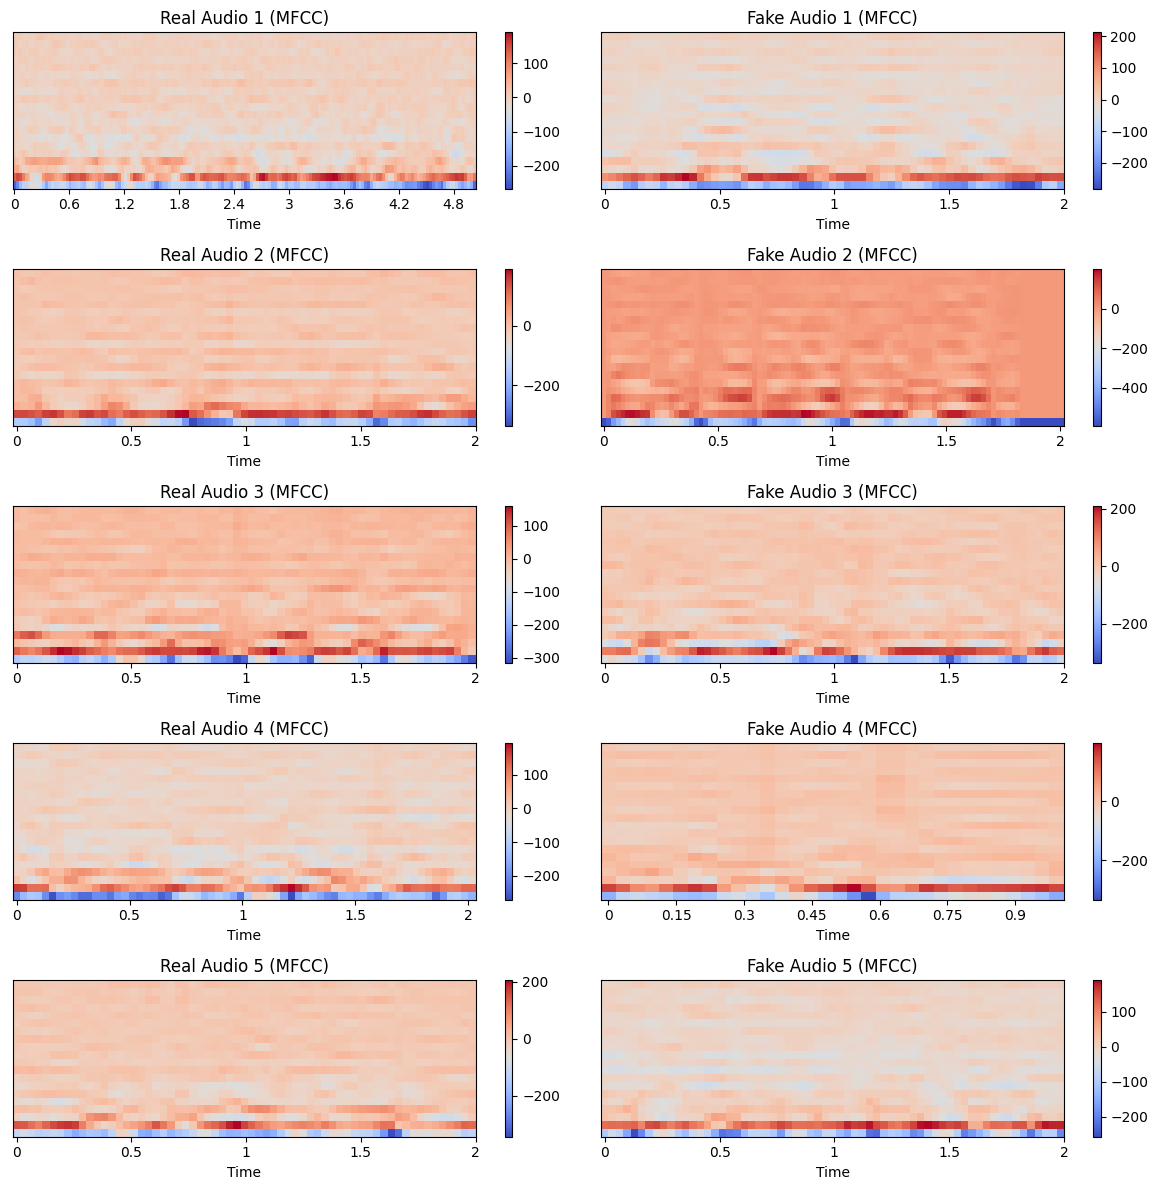

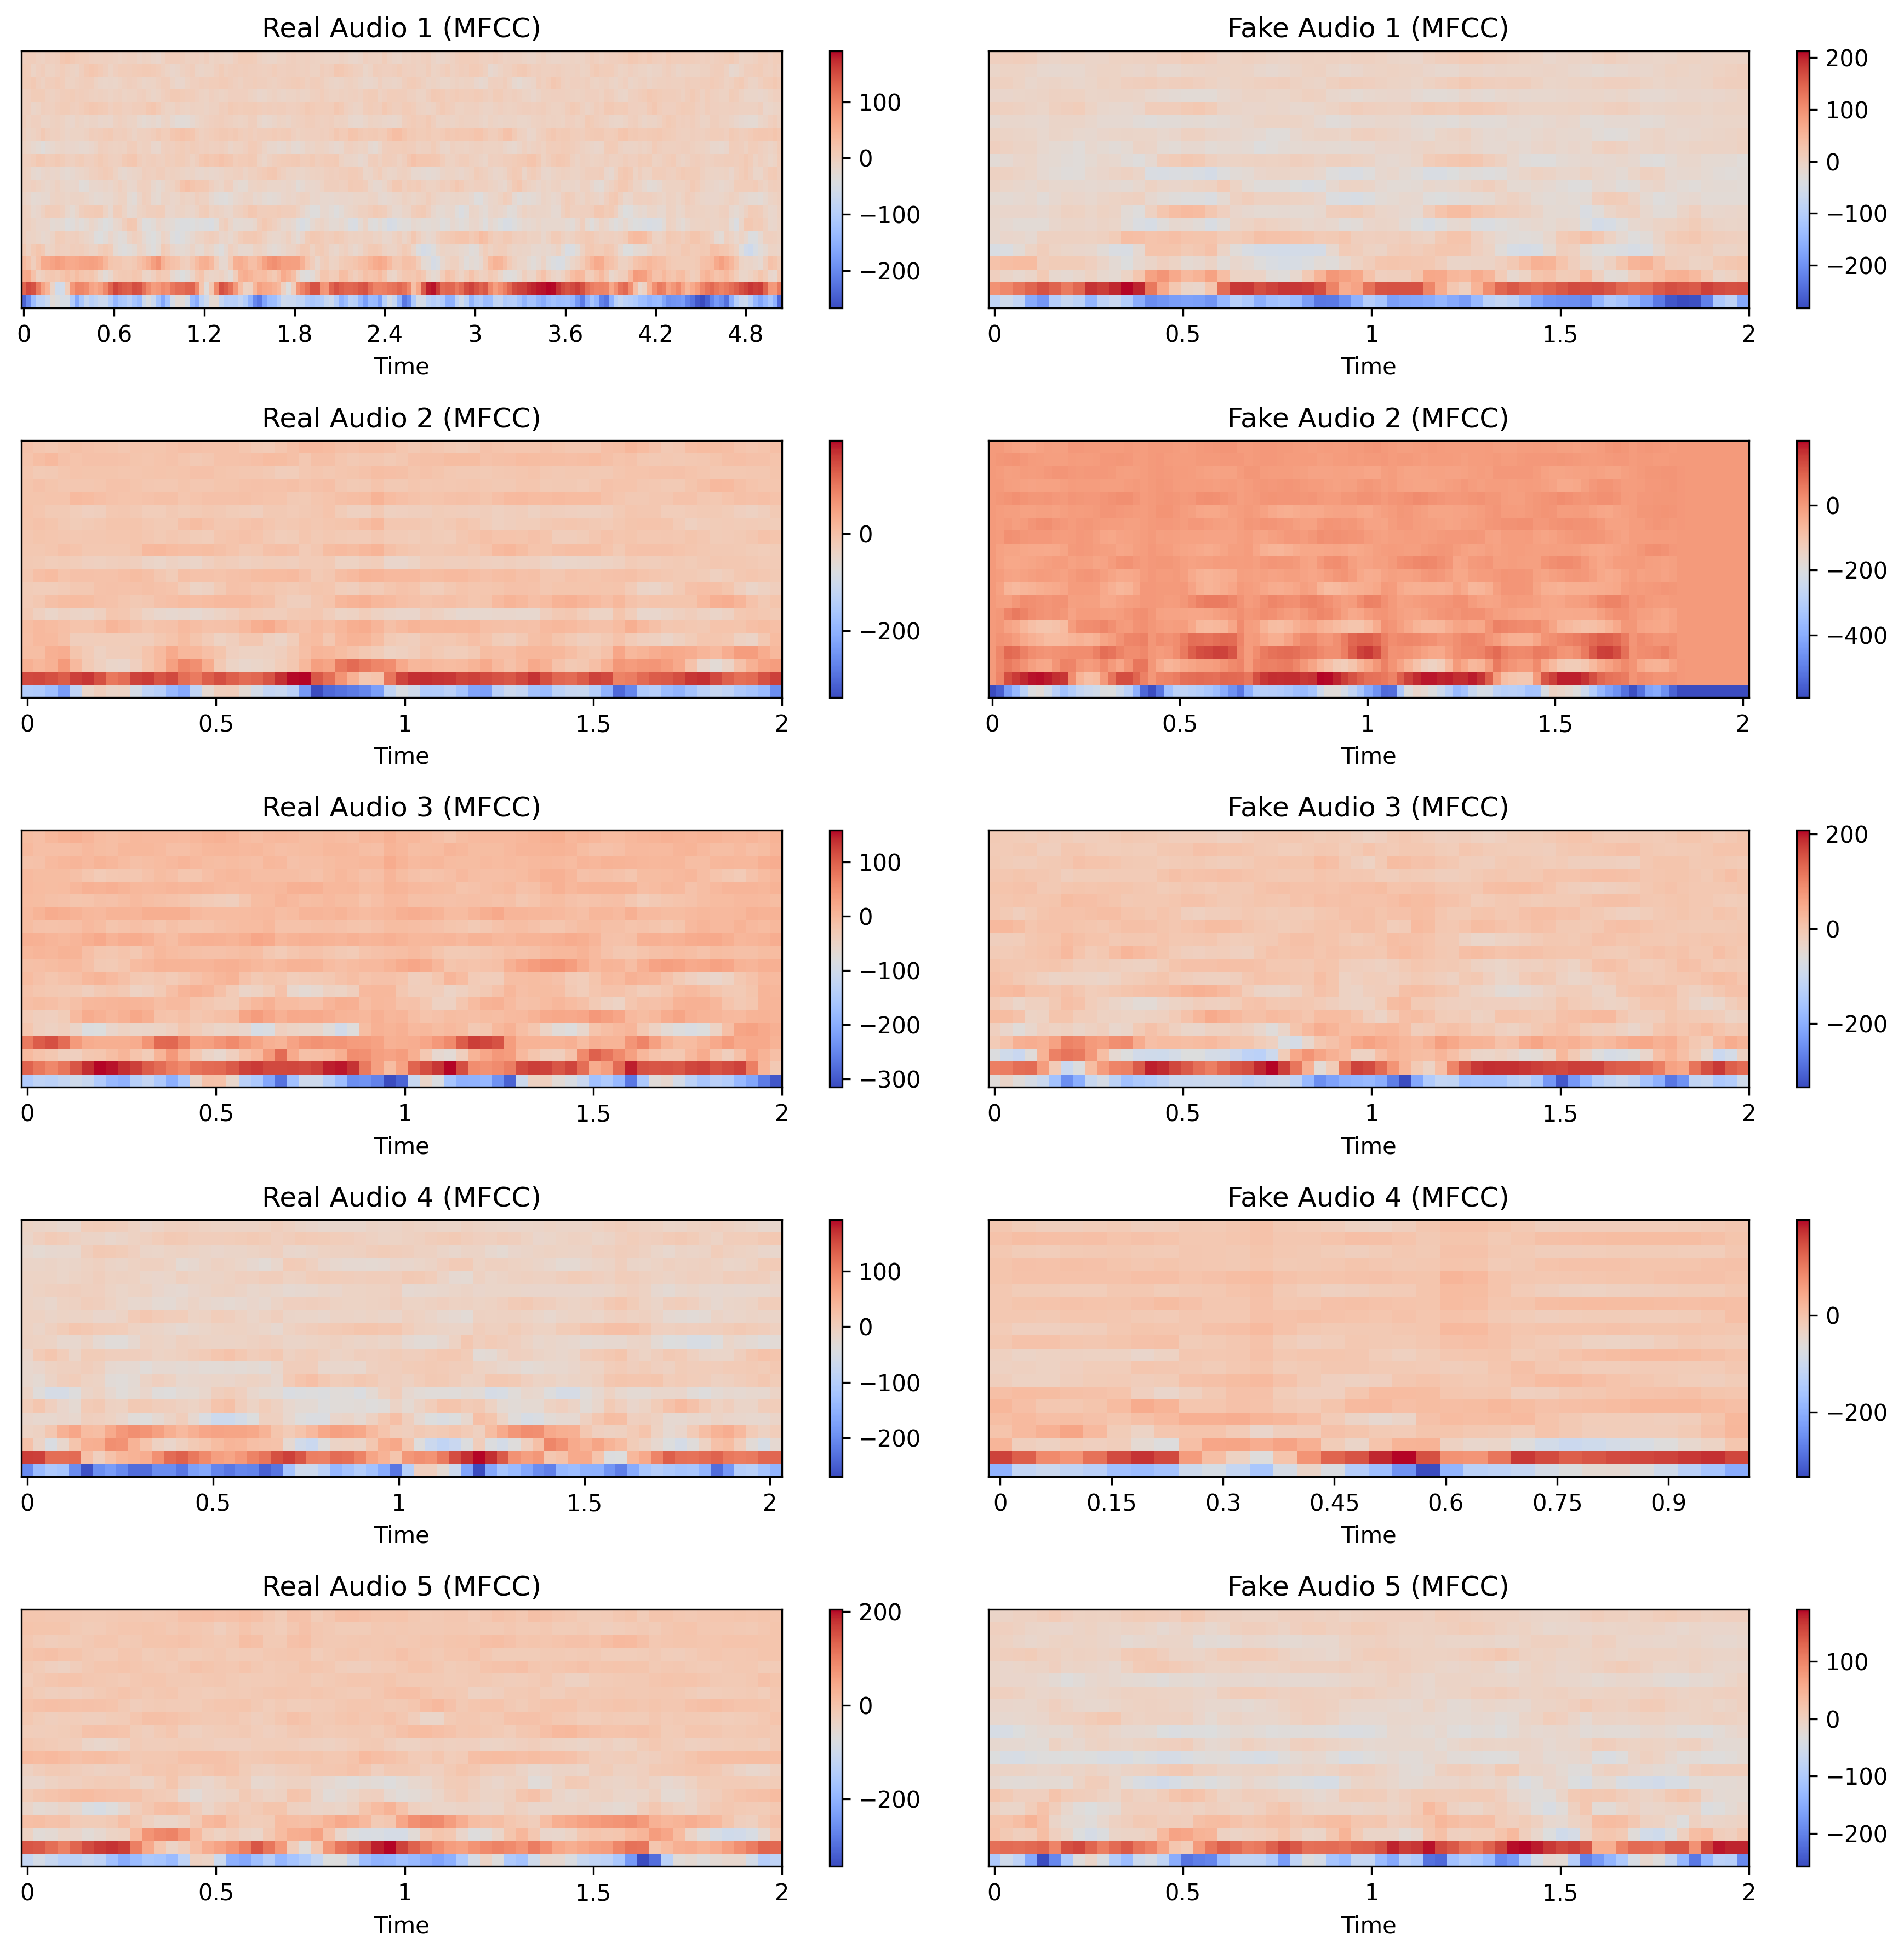

In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
import random
from IPython.display import Image

# ✅ Ensure GPU usage
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f"⚠️ {e}")
    print("✅ GPU is available and configured.")

# ✅ Dataset paths
datasets = [
    {'name': 'for-2sec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/'},
    {'name': 'for-norm', 'path': '/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/'},
    {'name': 'for-original', 'path': '/kaggle/input/the-fake-or-real-dataset/for-original/for-original/'},
    {'name': 'for-rerec', 'path': '/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/'},
]

# ✅ Function to load and visualize 5 random sample MFCCs from "real" and "fake"
def visualize_mfcc():
    real_samples, fake_samples = [], []

    # Collect random samples
    for dataset in datasets:
        for split in ['training', 'validation', 'testing']:
            for label in ['fake', 'real']:
                label_path = os.path.join(dataset['path'], split, label)
                if not os.path.exists(label_path):
                    continue
                files = [f for f in os.listdir(label_path) if f.endswith('.wav')]
                if files:
                    sample_file = os.path.join(label_path, random.choice(files))
                    if label == 'real':
                        real_samples.append((dataset['name'], split, label, sample_file))
                    else:
                        fake_samples.append((dataset['name'], split, label, sample_file))

    random.shuffle(real_samples)
    random.shuffle(fake_samples)

    plt.figure(figsize=(12, 12))

    for i in range(5):
        # Plot real audio MFCC
        if i < len(real_samples):
            dataset_name, split, label, sample_file = real_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

            plt.subplot(5, 2, 2 * i + 1)
            librosa.display.specshow(mfcc, sr=sr, x_axis='time')
            plt.colorbar()
            plt.title(f"Real Audio {i + 1} (MFCC)")

        # Plot fake audio MFCC
        if i < len(fake_samples):
            dataset_name, split, label, sample_file = fake_samples[i]
            audio, sr = librosa.load(sample_file, sr=None)
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

            plt.subplot(5, 2, 2 * i + 2)
            librosa.display.specshow(mfcc, sr=sr, x_axis='time')
            plt.colorbar()
            plt.title(f"Fake Audio {i + 1} (MFCC)")

    plt.tight_layout()

    # ✅ Save high-res figure in Kaggle working directory
    save_path = "/kaggle/working/mfcc_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📂 MFCC figure saved at: {save_path}")

    plt.show()

    # ✅ Show saved file inline
    display(Image(filename=save_path))

# Run function
visualize_mfcc()
\